In [1]:
import subprocess
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from concurrent.futures import ProcessPoolExecutor, as_completed

In [2]:
import os
import multiprocessing as mp

print("os.cpu_count():", os.cpu_count())
print("multiprocessing.cpu_count():", mp.cpu_count())


os.cpu_count(): 8
multiprocessing.cpu_count(): 8


In [3]:
# Paths / config
CPP_DIR = Path("../cpp")
BINARY = CPP_DIR / "mass_simulate"
OUT_DIR = Path("../output/unmod")
OUT_DIR.mkdir(parents=True, exist_ok=True)

A_VALUES = list(range(15, 26, 1 ))        # x-axis
B_VALUES = list(range(15, 26, 1))        # y-axis
N_SIMULATIONS = 10_000               # per (a,b)

In [4]:
def run_single(a: int, b: int, n: int) -> float:
    """
    Run ./mass_simulate a b n f and return success percentage.
    Program prints: 'success : <number>' to stderr.
    """
    result = subprocess.run(
        [str(BINARY), str(a), str(b), str(n), "f"],
        cwd=str(CPP_DIR),
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
        check=True,
    )

    # stderr contains: "success : <num>"
    success_line = result.stderr.strip().splitlines()[-1]
    # Example: "success : 8123"
    success_count = int(success_line.split(":")[1].strip())

    return 100.0 * success_count / n

In [5]:
# --- Parallel execution (8 workers) ---

heatmap = np.zeros((len(B_VALUES), len(A_VALUES)), dtype=float)
tasks = {}

print("Submitting jobs (parallel=8 workers)...")

with ProcessPoolExecutor(max_workers=8) as executor:
    for j, b in enumerate(B_VALUES):
        for i, a in enumerate(A_VALUES):
            fut = executor.submit(run_single, a, b, N_SIMULATIONS)
            tasks[fut] = (i, j, a, b)

    for fut in as_completed(tasks):
        i, j, a, b = tasks[fut]
        pct = fut.result()
        heatmap[j, i] = pct
        print(f"Running a={a}, b={b} for {N_SIMULATIONS} sims...  -> success = {pct:.2f}%")



Submitting jobs (parallel=8 workers)...


Running a=15, b=15 for 10000 sims...  -> success = 66.98%
Running a=16, b=15 for 10000 sims...  -> success = 67.28%
Running a=17, b=15 for 10000 sims...  -> success = 66.43%
Running a=18, b=15 for 10000 sims...  -> success = 67.01%
Running a=19, b=15 for 10000 sims...  -> success = 66.70%
Running a=20, b=15 for 10000 sims...  -> success = 68.02%
Running a=21, b=15 for 10000 sims...  -> success = 66.42%
Running a=22, b=15 for 10000 sims...  -> success = 67.78%
Running a=15, b=16 for 10000 sims...  -> success = 62.45%
Running a=16, b=16 for 10000 sims...  -> success = 62.47%
Running a=17, b=16 for 10000 sims...  -> success = 62.15%
Running a=23, b=15 for 10000 sims...  -> success = 66.41%
Running a=18, b=16 for 10000 sims...  -> success = 61.92%
Running a=24, b=15 for 10000 sims...  -> success = 67.11%
Running a=19, b=16 for 10000 sims...  -> success = 62.61%
Running a=25, b=15 for 10000 sims...  -> success = 66.70%
Running a=20, b=16 for 10000 sims...  -> success = 62.37%
Running a=21, 

In [6]:
df = pd.DataFrame(heatmap, index=B_VALUES, columns=A_VALUES)
df.index.name = "b"
df.columns.name = "a"

csv_path = OUT_DIR / f"heatmap_success_{A_VALUES[0]}-{A_VALUES[-1]}x{B_VALUES[0]}-{B_VALUES[-1]}_{N_SIMULATIONS}.csv"
df.to_csv(csv_path)

plt.figure(figsize=(10, 8))
sns.heatmap(
    df,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=0, vmax=100,
    cbar_kws={"label": "success rate (%)"}
)
plt.title("Success rate of mass_simulate over a×b grids")
plt.xlabel("a (grid width)")
plt.ylabel("b (grid height)")
plt.tight_layout()

png_path = OUT_DIR / f"mass_heatmap_{A_VALUES[0]}-{A_VALUES[-1]}x{B_VALUES[0]}-{B_VALUES[-1]}_{N_SIMULATIONS}.png"
plt.savefig(png_path, dpi=200)
plt.close()

print("\nDone!")
print("Saved CSV:", csv_path)
print("Saved heatmap:", png_path)


Done!
Saved CSV: ../output/unmod/heatmap_success_15-25x15-25_10000.csv
Saved heatmap: ../output/unmod/mass_heatmap_15-25x15-25_10000.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../output/unmod/heatmap_success_15-25x15-25_10000.csv")
matrix = np.matrix(df)
np.mean(matrix[:, 1:]), np.std(matrix[:, 1:])

(np.float64(62.8398347107438), np.float64(2.649449961151636))

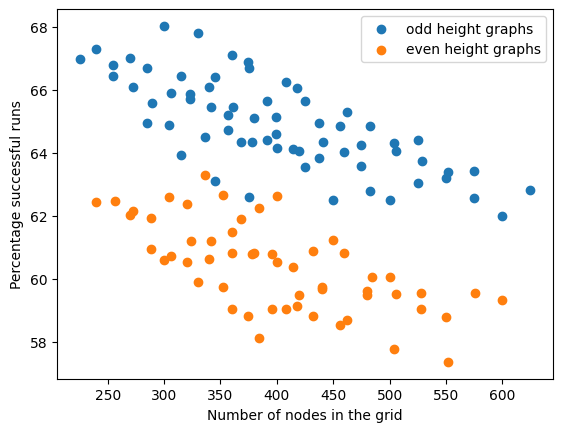

In [8]:
A_VALUES = list(range(15, 26, 2 )) 
B_VALUES = list(range(15, 26, 1 )) 
plt.scatter((np.transpose(len(B_VALUES)*[A_VALUES])*np.array(B_VALUES)).flatten(), np.array(matrix[::2, 1:]).flatten(),label="odd height graphs")
A_VALUES = list(range(16, 26, 2 )) 
B_VALUES = list(range(15, 26, 1 )) 
plt.scatter((np.transpose(len(B_VALUES)*[A_VALUES])*np.array(B_VALUES)).flatten(), np.array(matrix[1::2, 1:]).flatten(),label="even height graphs")
plt.legend()
plt.xlabel("Number of nodes in the grid")
plt.ylabel("Percentage successful runs")
plt.show()

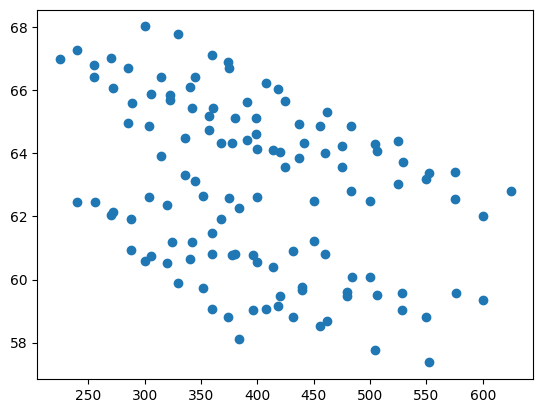

In [9]:
A_VALUES = list(range(15, 26, 1)) 
np.transpose(len(A_VALUES)*[A_VALUES])*np.array(A_VALUES)
x = np.transpose(len(A_VALUES)*[A_VALUES])*np.array(A_VALUES)
x = x.flatten()
y = np.array(matrix[:, 1:].flatten())[0]
points = list(zip(x, y))

plt.scatter(x, y)
plt.show()

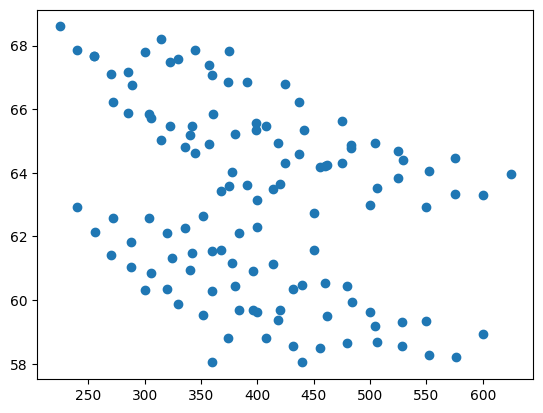

In [20]:
# Paths / config
CPP_DIR = Path("../cpp")
BINARY = CPP_DIR / "mod_start_mass_simulator"
OUT_DIR = Path("../output/mod_start")
OUT_DIR.mkdir(parents=True, exist_ok=True)

A_VALUES = list(range(15, 26, 1 ))        # x-axis
B_VALUES = list(range(15, 26, 1))        # y-axis
N_SIMULATIONS = 10_000               # per (a,b)
A_VALUES
def run_single(a: int, b: int, n: int) -> float:
    """
    Run ./mass_simulate a b n f and return success percentage.
    Program prints: 'success : <number>' to stderr.
    """
    result = subprocess.run(
        [str(BINARY), str(a), str(b), str(n), "f"],
        cwd=str(CPP_DIR),
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
        check=True,
    )

    # stderr contains: "success : <num>"
    success_line = result.stderr.strip().splitlines()[-1]
    # Example: "success : 8123"
    success_count = int(success_line.split(":")[1].strip())

    return 100.0 * success_count / n
# --- Parallel execution (5 workers) ---

heatmap = np.zeros((len(B_VALUES), len(A_VALUES)), dtype=float)
tasks = {}

print("Submitting jobs (parallel=5 workers)...")

with ProcessPoolExecutor(max_workers=5) as executor:
    for j, b in enumerate(B_VALUES):
        for i, a in enumerate(A_VALUES):
            fut = executor.submit(run_single, a, b, N_SIMULATIONS)
            tasks[fut] = (i, j, a, b)

    for fut in as_completed(tasks):
        i, j, a, b = tasks[fut]
        pct = fut.result()
        heatmap[j, i] = pct
        print(f"Running a={a}, b={b} for {N_SIMULATIONS} sims...  -> success = {pct:.2f}%")


df = pd.DataFrame(heatmap, index=B_VALUES, columns=A_VALUES)
df.index.name = "b"
df.columns.name = "a"

csv_path = OUT_DIR / f"mod_start_heatmap_success_{A_VALUES[0]}-{A_VALUES[-1]}x{B_VALUES[0]}-{B_VALUES[-1]}_{N_SIMULATIONS}.csv"
df.to_csv(csv_path)



Submitting jobs (parallel=5 workers)...


Running a=15, b=15 for 10000 sims...  -> success = 100.00%
Running a=16, b=15 for 10000 sims...  -> success = 100.00%
Running a=17, b=15 for 10000 sims...  -> success = 100.00%
Running a=18, b=15 for 10000 sims...  -> success = 100.00%
Running a=19, b=15 for 10000 sims...  -> success = 100.00%
Running a=20, b=15 for 10000 sims...  -> success = 100.00%
Running a=21, b=15 for 10000 sims...  -> success = 100.00%
Running a=22, b=15 for 10000 sims...  -> success = 100.00%
Running a=23, b=15 for 10000 sims...  -> success = 100.00%
Running a=24, b=15 for 10000 sims...  -> success = 100.00%
Running a=15, b=16 for 10000 sims...  -> success = 100.00%
Running a=16, b=16 for 10000 sims...  -> success = 100.00%
Running a=17, b=16 for 10000 sims...  -> success = 100.00%
Running a=25, b=15 for 10000 sims...  -> success = 100.00%
Running a=18, b=16 for 10000 sims...  -> success = 100.00%
Running a=19, b=16 for 10000 sims...  -> success = 100.00%
Running a=20, b=16 for 10000 sims...  -> success = 100.0

In [21]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=0, vmax=100,
    cbar_kws={"label": "success rate (%)"}
)
plt.title("Success rate of mass_simulate with modified start over a×b grids")
plt.xlabel("a (grid width)")
plt.ylabel("b (grid height)")
plt.tight_layout()

png_path = OUT_DIR / f"mod_start_mass_heatmap_{A_VALUES[0]}-{A_VALUES[-1]}x{B_VALUES[0]}-{B_VALUES[-1]}_{N_SIMULATIONS}.png"
plt.savefig(png_path, dpi=200)
plt.close()

print("\nDone!")
print("Saved CSV:", csv_path)
print("Saved heatmap:", png_path)



Done!
Saved CSV: ../output/mod_start/mod_start_heatmap_success_15-25x15-25_10000.csv
Saved heatmap: ../output/mod_start/mod_start_mass_heatmap_15-25x15-25_10000.png
